In [3]:
#Importação das bibliotecas:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Lendo o arquivo CSV:
df = pd.read_csv("student_habits_performance.csv")

In [5]:
#Visualizando os dados:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [7]:
#Tipos de dados:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [9]:
#Colunas númericas:
cols = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "sleep_hours",
    "attendance_percentage",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score",
]

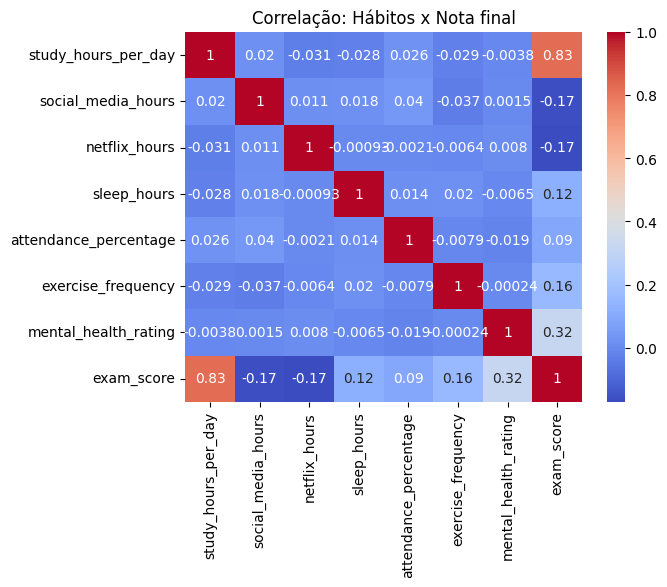

In [10]:
#Plotando mapa de correlação (heatmap):
sns.heatmap(df[cols].corr(), annot = True, cmap = "coolwarm")
plt.title("Correlação: Hábitos x Nota final")
plt.show()

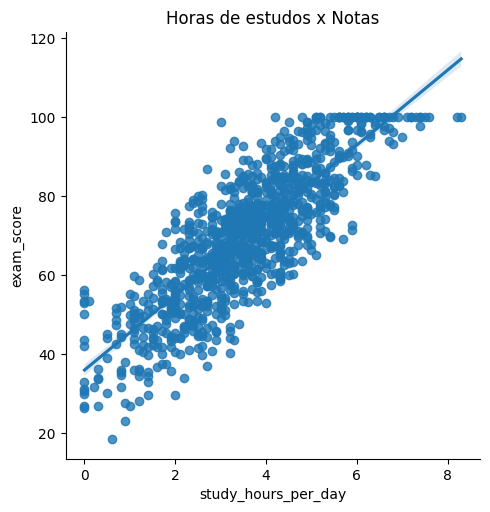

In [11]:
#Alunos que estudam mais tem melhor desempenho? 
#Gráfico de dispoersão co linha de regressão:
sns.lmplot(data=df, x = "study_hours_per_day", y ="exam_score")
plt.title("Horas de estudos x Notas")
plt.show()

In [13]:
#Comparação de médias das notas em relação a horas de estudos: acima de 5h x menos de 2h:
filtro_estudo_alto = df["study_hours_per_day"] > 5
filtro_estudo_baixo = df["study_hours_per_day"] < 2

grupo_estudo_alto = df[filtro_estudo_alto]["exam_score"]
grupo_estudo_baixo = df[filtro_estudo_baixo]["exam_score"]

print(f"A média de notas para alunos(as) que estudam acima de 5h é: {grupo_estudo_alto.mean():.2f}")
print(f"A média de notas para alunos(as) que estudam menos de 2h é: {grupo_estudo_baixo.mean():.2f}")


A média de notas para alunos(as) que estudam acima de 5h é: 90.79
A média de notas para alunos(as) que estudam menos de 2h é: 45.56


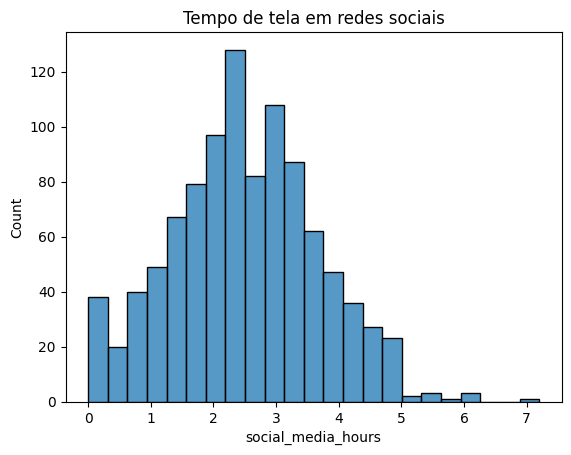

In [14]:
#O tempo gasto em redes sociais afeta o desempenho dos alunos ? 
#Distribuição de tempo médio em redes sociais (histograma)
sns.histplot(data=df, x="social_media_hours")
plt.title("Tempo de tela em redes sociais")
plt.show()


In [19]:
#Separando a média de notas por grupos de horas nas redes sociais:
#Intervalos(bins) = ["0-2h", "2h-4h", "4h-6h", "6h-8h"]
df["social_media_bin"]= pd.cut(
    df["social_media_hours"],
    bins = [0, 2, 4, 6, 8],
    labels = ["0-2h", "2h-4h", "4h-6h", "6h-8h"]
)

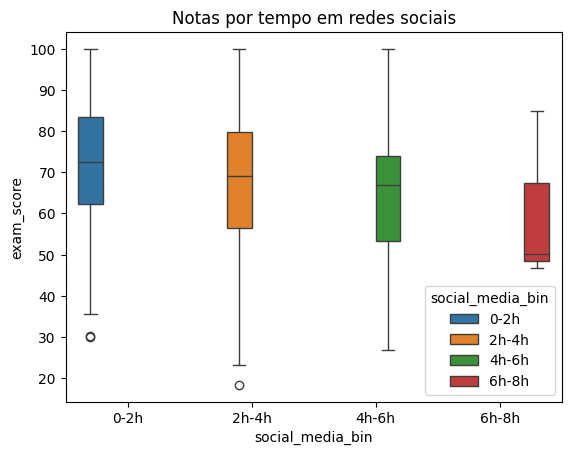

In [24]:
#Plotando o gráfico em blocos(boxplot):
sns.boxplot(x="social_media_bin", y="exam_score", data=df, hue= "social_media_bin")
plt.title("Notas por tempo em redes sociais")
plt.show()

/var/folders/4r/zds7bzb95_b05p6y0k3hw9lm0000gn/T/ipykernel_1803/1395164295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="exam_score", data=df, palette="Set2")


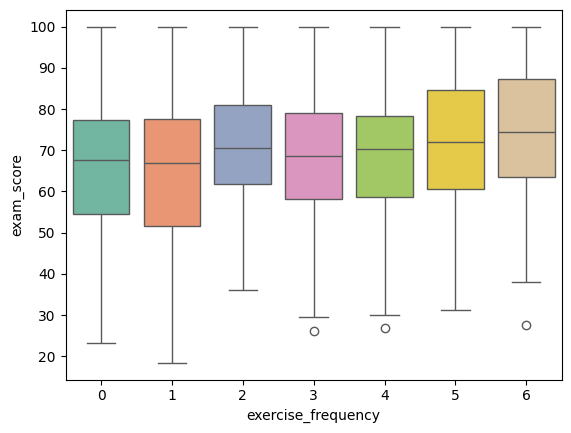

/var/folders/4r/zds7bzb95_b05p6y0k3hw9lm0000gn/T/ipykernel_1803/1395164295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="exam_score", data=df, palette="Set2")


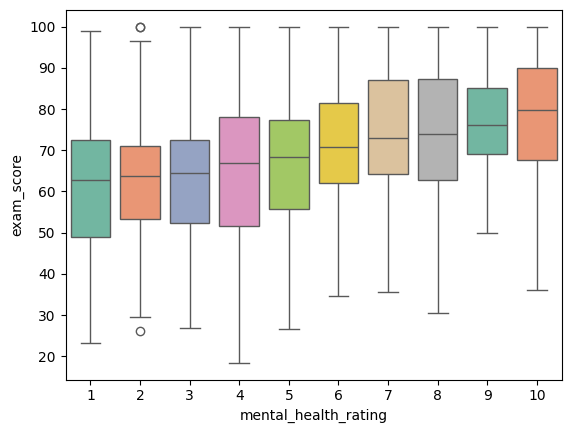

/var/folders/4r/zds7bzb95_b05p6y0k3hw9lm0000gn/T/ipykernel_1803/1395164295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="exam_score", data=df, palette="Set2")


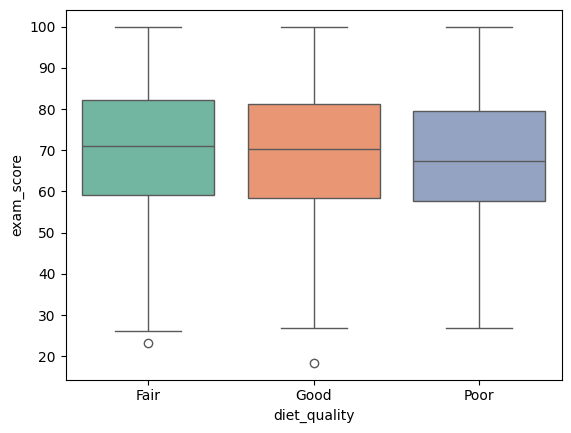

In [33]:
#Análise de Frequência de exercícios, Saúde Mental e Qualidade de dieta em relação as Notas:
for col in ["exercise_frequency", "mental_health_rating", "diet_quality"]:
    sns.boxplot(x=col, y="exam_score", data=df, palette="Set2")
    plt.show()

In [34]:
#Estatística por gênero (média e desvio padrão):
df.groupby(["gender"])["exam_score"].agg(["mean", "std"])

,mean,std
gender,,
Female,69.741372,16.899351
Male,69.368344,17.150875
Other,70.647619,13.755890
